In [2]:
import os, warnings, json, pickle, math
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['GLOG_minloglevel']     = '3'
warnings.filterwarnings('ignore')
 
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import tensorflow as tf
import keras
from keras import layers, models, regularizers
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from collections import deque
import urllib.request
 
print("numpy:",      np.__version__)
print("tensorflow:", tf.__version__)
print("mediapipe:",  mp.__version__)
print("GPU:",        tf.config.list_physical_devices('GPU'))

numpy: 2.2.6
tensorflow: 2.18.0
mediapipe: 0.10.33
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
SEQ_LEN    = 30     
N_FEATURES = 14      
BATCH_SIZE = 64
EPOCHS     = 80
LR_PEAK    = 2e-4   
 
DATASET_BASE  = '/Users/stevennn/Downloads/DAiSEE/DataSet'
LABELS_BASE   = '/Users/stevennn/Downloads/DAiSEE/Labels'
PERSONAL_DIR  = './my_dataset'
CACHE_DIR     = './landmark_cache'
MODEL_PATH    = 'face_landmarker.task'
 
os.makedirs(CACHE_DIR, exist_ok=True)
 

ENGAGEMENT_MAP   = {0: 0, 1: 0, 2: 1, 3: 2}  
BOREDOM_MAP      = {0: 0, 1: 1, 2: 1, 3: 1}  
ENGAGEMENT_NAMES = ['Low', 'Moderate', 'High']
BOREDOM_NAMES    = ['Not Bored', 'Bored']
 
ENG_MAP_P = {'Low': 0, 'Moderate': 1, 'High': 2}
BOR_MAP_P = {'Not Bored': 0, 'Bored': 1}
 
print("Config loaded.")

Config loaded.


In [4]:
if not os.path.exists(MODEL_PATH):
    print("Downloading MediaPipe face landmarker (~30MB)...")
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/'
        'face_landmarker/face_landmarker/float16/1/face_landmarker.task',
        MODEL_PATH
    )
    print("Downloaded.")
else:
    print("Model already downloaded.")

Model already downloaded.


In [5]:
class LandmarkExtractor:

    LEFT_EYE   = [362, 385, 387, 263, 373, 380]
    RIGHT_EYE  = [33,  160, 158, 133, 153, 144]
    MOUTH      = [61,  291,  39, 181,   0,  17]
    LEFT_BROW  = [336, 296, 334, 293, 300]
    RIGHT_BROW = [70,   63, 105,  66, 107]
    NOSE_TIP   = 1
    CHIN       = 152
    LEFT_EYE_C = 263
    RIGHT_EYE_C= 33
    LEFT_MOUTH = 61
    RIGHT_MOUTH= 291
 
    def __init__(self):
        opts = mp_vision.FaceLandmarkerOptions(
            base_options=mp_python.BaseOptions(model_asset_path=MODEL_PATH),
            output_face_blendshapes=False,
            output_facial_transformation_matrixes=False,
            num_faces=1,
            min_face_detection_confidence=0.5,
            min_face_presence_confidence=0.5,
            min_tracking_confidence=0.5,
            running_mode=mp_vision.RunningMode.IMAGE
        )
        self.detector  = mp_vision.FaceLandmarker.create_from_options(opts)
        self._prev_ear = None
 
    def reset(self):
        self._prev_ear = None
 
    @staticmethod
    def _ear(lm, idx, w, h):
        p = np.array([[lm[i].x * w, lm[i].y * h] for i in idx])
        A = np.linalg.norm(p[1] - p[5])
        B = np.linalg.norm(p[2] - p[4])
        C = np.linalg.norm(p[0] - p[3])
        return (A + B) / (2.0 * C + 1e-6)
 
    @staticmethod
    def _mar(lm, idx, w, h):
        p = np.array([[lm[i].x * w, lm[i].y * h] for i in idx])
        A = np.linalg.norm(p[1] - p[5])
        B = np.linalg.norm(p[2] - p[4])
        C = np.linalg.norm(p[0] - p[3])
        return (A + B) / (2.0 * C + 1e-6)
 
    @staticmethod
    def _brow_raise(lm, brow_idx, eye_idx, w, h):
        brow_y = np.mean([lm[i].y * h for i in brow_idx])
        eye_y  = np.mean([lm[i].y * h for i in eye_idx])
        return (eye_y - brow_y) / (h + 1e-6)
 
    @staticmethod
    def _head_pose(lm, shape):
        h, w = shape[:2]
        model_pts = np.array([
            ( 0.0,   0.0,   0.0),
            ( 0.0, -63.6, -12.5),
            (-43.3,  32.7, -26.0),
            ( 43.3,  32.7, -26.0),
            (-28.9, -28.9, -24.1),
            ( 28.9, -28.9, -24.1),
        ], dtype=np.float64)
        img_pts = np.array(
            [[lm[i].x * w, lm[i].y * h] for i in [1,152,263,33,61,291]],
            dtype=np.float64
        )
        f   = float(w)
        cam = np.array([[f,0,w/2],[0,f,h/2],[0,0,1]], dtype=np.float64)
        ok, rvec, _ = cv2.solvePnP(model_pts, img_pts, cam,
                                    np.zeros((4,1)),
                                    flags=cv2.SOLVEPNP_ITERATIVE)
        if not ok:
            return 0.0, 0.0, 0.0
        rmat, _ = cv2.Rodrigues(rvec)
        angles, *_ = cv2.RQDecomp3x3(rmat)
        return float(angles[0]), float(angles[1]), float(angles[2])
 
    def extract(self, frame_bgr):
        h, w = frame_bgr.shape[:2]
        rgb  = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        res  = self.detector.detect(
            mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        )
        if not res.face_landmarks:
            self._prev_ear = None
            return None
 
        lm = res.face_landmarks[0]
 
        l_ear = self._ear(lm, self.LEFT_EYE,  w, h)
        r_ear = self._ear(lm, self.RIGHT_EYE, w, h)
        avg   = (l_ear + r_ear) / 2.0
        vel   = (avg - self._prev_ear) if self._prev_ear is not None else 0.0
        self._prev_ear = avg
 
        mar          = self._mar(lm, self.MOUTH, w, h)
        pitch, yaw, roll = self._head_pose(lm, frame_bgr.shape)
 
        lb = self._brow_raise(lm, self.LEFT_BROW,  self.LEFT_EYE,  w, h)
        rb = self._brow_raise(lm, self.RIGHT_BROW, self.RIGHT_EYE, w, h)
 
        nc  = (lm[self.CHIN].y * h - lm[self.NOSE_TIP].y * h) / (h + 1e-6)
        ied = abs(lm[self.LEFT_EYE_C].x - lm[self.RIGHT_EYE_C].x)
 
        return np.array([
            l_ear, r_ear, avg, vel,
            mar,
            pitch / 90.0, yaw / 90.0, roll / 90.0,
            lb, rb, (lb + rb) / 2.0,
            nc, ied, 1.0
        ], dtype=np.float32)
 
 
extractor = LandmarkExtractor()
print("LandmarkExtractor ready.")

LandmarkExtractor ready.


W0000 00:00:1774221428.542361   18743 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1774221428.581355   18743 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774221428.586894   18747 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774221428.594962   18745 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [6]:
def extract_features_from_video(video_path, extractor, n_frames=SEQ_LEN):
    extractor.reset()
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release(); return None
 
    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames  = []
 
    for fi in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret or frame is None:
            cap.release(); return None
        feat = extractor.extract(frame)
        frames.append(feat if feat is not None
                      else np.zeros(N_FEATURES, dtype=np.float32))
 
    cap.release()
    return np.stack(frames) if len(frames) == n_frames else None
 
 
def build_video_index(video_dir):
    idx = {}
    for root, _, files in os.walk(video_dir):
        for f in files:
            if f.endswith(('.avi', '.mp4')):
                idx[f] = os.path.join(root, f)
    return idx
 
 
def extract_and_cache(df, video_dir, split_name,
                      eng_map, bor_map, extractor):
    cache = os.path.join(CACHE_DIR, f'daisee_{split_name}.npz')
    if os.path.exists(cache):
        print(f"  Loading cached {split_name}...")
        d = np.load(cache, allow_pickle=True)
        return d['X'], d['y_eng'], d['y_bor']
 
    print(f"  Extracting {split_name} (first time — ~20-40 min)...")
    vidx = build_video_index(video_dir)
    print(f"  Found {len(vidx)} videos")
 
    X, y_eng, y_bor, skipped = [], [], [], 0
    for i, (_, row) in enumerate(df.iterrows()):
        path = vidx.get(row['ClipID'])
        if not path:
            skipped += 1; continue
        feat = extract_features_from_video(path, extractor)
        if feat is None:
            skipped += 1; continue
        X.append(feat)
        y_eng.append(eng_map[int(row['Engagement'])])
        y_bor.append(bor_map[int(row['Boredom'])])
        if (i + 1) % 200 == 0:
            print(f"    {i+1}/{len(df)} | skipped: {skipped}")
 
    X     = np.array(X,     dtype=np.float32)
    y_eng = np.array(y_eng, dtype=np.int32)
    y_bor = np.array(y_bor, dtype=np.int32)
    np.savez_compressed(cache, X=X, y_eng=y_eng, y_bor=y_bor)
    print(f"  Cached {len(X)} samples. Skipped: {skipped}")
    return X, y_eng, y_bor

In [7]:
train_df = pd.read_csv(f'{LABELS_BASE}/TrainLabels.csv')
val_df   = pd.read_csv(f'{LABELS_BASE}/ValidationLabels.csv')
test_df  = pd.read_csv(f'{LABELS_BASE}/TestLabels.csv')
for df in [train_df, val_df, test_df]:
    df.columns = df.columns.str.strip()
 
print(f"DAiSEE — Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
 
print("\n=== Train ===")
X_d_train, y_eng_d_train, y_bor_d_train = extract_and_cache(
    train_df, f'{DATASET_BASE}/Train', 'train',
    ENGAGEMENT_MAP, BOREDOM_MAP, extractor)
 
print("\n=== Val ===")
X_d_val, y_eng_d_val, y_bor_d_val = extract_and_cache(
    val_df, f'{DATASET_BASE}/Validation', 'val',
    ENGAGEMENT_MAP, BOREDOM_MAP, extractor)
 
print("\n=== Test ===")
X_d_test, y_eng_d_test, y_bor_d_test = extract_and_cache(
    test_df, f'{DATASET_BASE}/Test', 'test',
    ENGAGEMENT_MAP, BOREDOM_MAP, extractor)
 
print(f"\nDAiSEE shapes — Train: {X_d_train.shape} | "
      f"Val: {X_d_val.shape} | Test: {X_d_test.shape}")
 

DAiSEE — Train: 5358 | Val: 1429 | Test: 1784

=== Train ===
  Loading cached train...

=== Val ===
  Loading cached val...

=== Test ===
  Loading cached test...

DAiSEE shapes — Train: (5358, 30, 14) | Val: (1429, 30, 14) | Test: (1784, 30, 14)


In [8]:
def load_personal_split(split_name, extractor):
    cache = os.path.join(CACHE_DIR, f'personal_{split_name}.npz')
    if os.path.exists(cache):
        print(f"  Loading cached personal {split_name}...")
        d = np.load(cache, allow_pickle=True)
        return d['X'], d['y_eng'], d['y_bor']
 
    labels_path = os.path.join(PERSONAL_DIR, f'{split_name}_labels.json')
    if not os.path.exists(labels_path):
        print(f"  No personal {split_name} data found.")
        return None, None, None
 
    entries = json.load(open(labels_path))
    X, y_eng, y_bor = [], [], []
 
    for entry in entries:
        path = os.path.join(PERSONAL_DIR, 'videos', entry['clip'])
        if not os.path.exists(path):
            continue
        feat = extract_features_from_video(path, extractor)
        if feat is None:
            continue
        X.append(feat)
        y_eng.append(ENG_MAP_P[entry['engagement']])
        y_bor.append(BOR_MAP_P[entry['boredom']])
 
    if not X:
        print(f"  No valid clips for personal {split_name}")
        return None, None, None
 
    X     = np.array(X,     dtype=np.float32)
    y_eng = np.array(y_eng, dtype=np.int32)
    y_bor = np.array(y_bor, dtype=np.int32)
    np.savez_compressed(cache, X=X, y_eng=y_eng, y_bor=y_bor)
    print(f"  Personal {split_name}: {len(X)} clips")
    return X, y_eng, y_bor
 
 
print("\n=== Personal data ===")
X_p_train, y_eng_p_train, y_bor_p_train = load_personal_split('train', extractor)
X_p_val,   y_eng_p_val,   y_bor_p_val   = load_personal_split('val',   extractor)
X_p_test,  y_eng_p_test,  y_bor_p_test  = load_personal_split('test',  extractor)
 
has_personal = X_p_train is not None
print(f"\nPersonal data available: {has_personal}")
 


=== Personal data ===
  No personal train data found.
  No personal val data found.
  No personal test data found.

Personal data available: False


In [9]:
scaler  = StandardScaler()
N, T, F = X_d_train.shape
 
# Fit scaler on DAiSEE train only
X_d_train_s = scaler.fit_transform(
    X_d_train.reshape(-1, F)).reshape(N, T, F)
 
def scale(X):
    if X is None: return None
    n = X.shape[0]
    return scaler.transform(X.reshape(-1, F)).reshape(n, T, F)
 
X_d_val_s  = scale(X_d_val)
X_d_test_s = scale(X_d_test)
X_p_train_s = scale(X_p_train)
X_p_val_s   = scale(X_p_val)
X_p_test_s  = scale(X_p_test)
 
with open('feature_scaler_v5.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved.")

Scaler saved.


In [10]:
def get_weights(y):
    classes = np.unique(y)
    w = compute_class_weight('balanced', classes=classes, y=y)
    return dict(zip(classes.tolist(), w.tolist()))
 
if has_personal:
    y_eng_all = np.concatenate([y_eng_d_train, y_eng_p_train])
    y_bor_all = np.concatenate([y_bor_d_train, y_bor_p_train])
else:
    y_eng_all = y_eng_d_train
    y_bor_all = y_bor_d_train
 
eng_weights = get_weights(y_eng_all)
bor_weights = get_weights(y_bor_all)
 
print("Engagement weights:", {k: round(v,3) for k,v in eng_weights.items()})
print("Boredom weights:",    {k: round(v,3) for k,v in bor_weights.items()})
 

Engagement weights: {0: 7.231, 1: 0.682, 2: 0.716}
Boredom weights: {0: 1.101, 1: 0.916}


In [11]:
def build_sample_weights(y_eng, y_bor, eng_w, bor_w, multiplier=1.0):
    n = len(y_eng)
    w = np.ones(n, dtype=np.float32)
    for i in range(n):
        we = eng_w.get(int(y_eng[i]), 1.0)
        wb = bor_w.get(int(y_bor[i]), 1.0)
        w[i] = (we + wb) / 2.0
    w *= multiplier
    return w / (w.mean() + 1e-8)
 
 
def oversample_minority(X, y_eng, y_bor, target_ratio=0.5):
    """Hard oversample minority engagement classes."""
    unique, counts = np.unique(y_eng, return_counts=True)
    target = int(counts.max() * target_ratio)
    X_out, ye_out, yb_out = [X], [y_eng], [y_bor]
    for cls, cnt in zip(unique, counts):
        if cnt < target:
            idx   = np.where(y_eng == cls)[0]
            extra = resample(idx, n_samples=target-cnt,
                             replace=True, random_state=42)
            X_out.append(X[extra])
            ye_out.append(y_eng[extra])
            yb_out.append(y_bor[extra])
            print(f"  Oversampled Engagement {ENGAGEMENT_NAMES[cls]}: "
                  f"{cnt} → {cnt + (target-cnt)}")
    return (np.vstack(X_out),
            np.concatenate(ye_out),
            np.concatenate(yb_out))
 
 
print("\n=== Building combined training set ===")
 
# Step 1 — oversample DAiSEE minorities
print("Oversampling DAiSEE minorities:")
X_d_os, y_eng_d_os, y_bor_d_os = oversample_minority(
    X_d_train_s, y_eng_d_train, y_bor_d_train, target_ratio=0.5)
 
sw_daisee = build_sample_weights(
    y_eng_d_os, y_bor_d_os, eng_weights, bor_weights, multiplier=1.0)
 
# Step 2 — add personal data with 3× weight
if has_personal:
    print("\nAdding personal clips (3× weight):")
    sw_personal = build_sample_weights(
        y_eng_p_train, y_bor_p_train,
        eng_weights, bor_weights, multiplier=3.0)
 
    X_train_final    = np.vstack([X_d_os, X_p_train_s])
    y_eng_train_final = np.concatenate([y_eng_d_os, y_eng_p_train])
    y_bor_train_final = np.concatenate([y_bor_d_os, y_bor_p_train])
    sw_final          = np.concatenate([sw_daisee, sw_personal])
else:
    X_train_final    = X_d_os
    y_eng_train_final = y_eng_d_os
    y_bor_train_final = y_bor_d_os
    sw_final          = sw_daisee
 
# Shuffle
idx               = np.random.permutation(len(X_train_final))
X_train_final     = X_train_final[idx]
y_eng_train_final = y_eng_train_final[idx]
y_bor_train_final = y_bor_train_final[idx]
sw_final          = sw_final[idx]
 
if has_personal and X_p_val_s is not None:
    X_val_final     = np.vstack([X_d_val_s, X_p_val_s])
    y_eng_val_final = np.concatenate([y_eng_d_val, y_eng_p_val])
    y_bor_val_final = np.concatenate([y_bor_d_val, y_bor_p_val])
else:
    X_val_final     = X_d_val_s
    y_eng_val_final = y_eng_d_val
    y_bor_val_final = y_bor_d_val
 
print(f"\nFinal training set:  {len(X_train_final)} samples")
print(f"Final validation:    {len(X_val_final)} samples")
 
# Engagement distribution after combining
print("\nEngagement distribution in final train:")
for cls, name in enumerate(ENGAGEMENT_NAMES):
    n = (y_eng_train_final == cls).sum()
    print(f"  {name}: {n} ({n/len(y_eng_train_final)*100:.1f}%)")
 


=== Building combined training set ===
Oversampling DAiSEE minorities:
  Oversampled Engagement Low: 247 → 1308

Final training set:  6419 samples
Final validation:    1429 samples

Engagement distribution in final train:
  Low: 1308 (20.4%)
  Moderate: 2617 (40.8%)
  High: 2494 (38.9%)


In [12]:
def build_model(seq_len=SEQ_LEN, n_features=N_FEATURES):

    inputs = layers.Input(shape=(seq_len, n_features), name='landmarks')
 
    # Feature projection — expand from 14 to 64 dims before LSTM
    x = layers.Dense(64, name='proj')(inputs)
    x = layers.LayerNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.1)(x)
 
    # BiLSTM stack — 3 layers for richer temporal modelling
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.3,
                    recurrent_dropout=0.1), name='bilstm_1')(x)
    x = layers.LayerNormalization()(x)
 
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.3,
                    recurrent_dropout=0.1), name='bilstm_2')(x)
    x = layers.LayerNormalization()(x)
 
    x = layers.Bidirectional(
        layers.LSTM(32, return_sequences=True, dropout=0.2),
        name='bilstm_3')(x)   # (batch, seq, 64)
 
    def task_attention(x, name):
        score  = layers.Dense(1, activation='tanh', name=f'{name}_attn_score')(x)
        weight = layers.Softmax(axis=1, name=f'{name}_attn_w')(score)
        ctx    = layers.Multiply()([x, weight])
        return layers.Lambda(lambda z: tf.reduce_sum(z, axis=1),
                             name=f'{name}_ctx')(ctx)
 
    eng_ctx = task_attention(x, 'eng')
    bor_ctx = task_attention(x, 'bor')
 
    # Shared dense trunk with residual
    def trunk(ctx, name):
        h  = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4),
                          name=f'{name}_h1')(ctx)
        h  = layers.LayerNormalization()(h)
        h  = layers.Activation('relu')(h)
        h  = layers.Dropout(0.3)(h)
        h2 = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4),
                          name=f'{name}_h2')(h)
        h2 = layers.LayerNormalization()(h2)
        # Residual: add h to h2 (same dim)
        out = layers.Add()([h, h2])
        out = layers.Activation('relu')(out)
        out = layers.Dropout(0.2)(out)
        return out
 
    eng_feat = trunk(eng_ctx, 'eng')
    bor_feat = trunk(bor_ctx, 'bor')
 
    # Output heads
    eng_out = layers.Dense(
        3, activation='softmax', name='engagement',
        bias_initializer=tf.keras.initializers.Constant(
            np.log(np.ones(3) / 3))           # uniform prior init
    )(eng_feat)
 
    bor_out = layers.Dense(
        2, activation='softmax', name='boredom',
        bias_initializer=tf.keras.initializers.Constant(
            np.log(np.ones(2) / 2))
    )(bor_feat)
 
    model = models.Model(inputs=inputs,
                         outputs={'engagement': eng_out, 'boredom': bor_out},
                         name='EngageTrack_v5')
    return model
 
 
model = build_model()
model.summary()
print(f"\nTotal params: {model.count_params():,}")

I0000 00:00:1774221428.721724   16947 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1774221428.721915   16947 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "EngageTrack_v5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ landmarks           │ (None, 30, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj (Dense)        │ (None, 30, 64)    │        960 │ landmarks[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 64)    │        128 │ proj[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 30, 64)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 64)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 30, 256)   │    197,632 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 256)   │        512 │ bilstm_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 30, 128)   │    164,352 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 128)   │        256 │ bilstm_2[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_3            │ (None, 30, 64)    │     41,216 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bor_attn_score      │ (None, 30, 1)     │         65 │ bilstm_3[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eng_attn_score      │ (None, 30, 1)     │         65 │ bilstm_3[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bor_attn_w          │ (None, 30, 1)     │          0 │ bor_attn_score[0… │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eng_attn_w          │ (None, 30, 1)     │          0 │ eng_attn_score[0… │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 30, 64)    │          0 │ bilstm_3[0][0],   │
│ (Multiply)          │                   │            │ bor_attn_w[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 30, 64)    │          0 │ bilstm_3[0][0],   │
│                     │                   │            │ eng_attn_w[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bor_ctx (Lambda)    │ (None, 64)        │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eng_ctx (Lambda)    │ (None, 64)        │          0 │ multiply[0][0]  

 Total params: 422,663 (1.61 MB)

 Trainable params: 422,663 (1.61 MB)

 Non-trainable params: 0 (0.00 B)


Total params: 422,663


In [13]:
class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, warmup_steps, total_steps):
        self.peak_lr      = peak_lr
        self.warmup_steps = float(warmup_steps)
        self.total_steps  = float(total_steps)
 
    def __call__(self, step):
        step    = tf.cast(step, tf.float32)
        warmup  = self.peak_lr * (step / self.warmup_steps)
        cosine  = self.peak_lr * 0.5 * (
            1 + tf.math.cos(math.pi * (step - self.warmup_steps)
                            / (self.total_steps - self.warmup_steps + 1e-6)))
        return tf.where(step < self.warmup_steps, warmup, cosine)
 
    def get_config(self):
        return {'peak_lr': self.peak_lr,
                'warmup_steps': self.warmup_steps,
                'total_steps':  self.total_steps}
 
 
steps_per_epoch = len(X_train_final) // BATCH_SIZE
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = steps_per_epoch * 5
 
schedule = WarmupCosineDecay(LR_PEAK, warmup_steps, total_steps)
 
model.compile(
    optimizer=keras.optimizers.Adam(schedule),
    loss={

        'engagement': keras.losses.CategoricalCrossentropy(
            label_smoothing=0.1, from_logits=False),
        'boredom':    keras.losses.CategoricalCrossentropy(
            label_smoothing=0.1, from_logits=False),
    },
    loss_weights={'engagement': 1.5, 'boredom': 0.8},
    metrics={
        'engagement': ['accuracy'],
        'boredom':    ['accuracy'],
    }
)
print("Compiled with warmup cosine schedule + label smoothing.") 

Compiled with warmup cosine schedule + label smoothing.


In [14]:
def to_onehot(y, n_classes):
    return tf.keras.utils.to_categorical(y, num_classes=n_classes)
 
y_eng_train_oh = to_onehot(y_eng_train_final, 3)
y_bor_train_oh = to_onehot(y_bor_train_final, 2)
y_eng_val_oh   = to_onehot(y_eng_val_final,   3)
y_bor_val_oh   = to_onehot(y_bor_val_final,   2)
 
print("Labels one-hot encoded.")
print(f"  y_eng_train_oh: {y_eng_train_oh.shape}")
print(f"  y_bor_train_oh: {y_bor_train_oh.shape}")
 

Labels one-hot encoded.
  y_eng_train_oh: (6419, 3)
  y_bor_train_oh: (6419, 2)


In [17]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_engagement_accuracy',
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'engagetrack_v5_best.keras',
        monitor='val_engagement_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
]

print("Callbacks ready.")
 

Callbacks ready.


In [18]:
print("=" * 60)
print("Training EngageTrack v5")
print(f"  Train: {len(X_train_final)} | Val: {len(X_val_final)}")
print(f"  Personal data: {'yes' if has_personal else 'no'}")
print("=" * 60)
 
history = model.fit(
    X_train_final,
    {'engagement': y_eng_train_oh, 'boredom': y_bor_train_oh},
    sample_weight=sw_final,
    validation_data=(
        X_val_final,
        {'engagement': y_eng_val_oh, 'boredom': y_bor_val_oh}
    ),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Training EngageTrack v5
  Train: 6419 | Val: 1429
  Personal data: no
Epoch 1/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - boredom_accuracy: 0.6065 - boredom_loss: 0.6004 - engagement_accuracy: 0.2814 - engagement_loss: 1.0035 - loss: 2.0115
Epoch 1: val_engagement_accuracy improved from None to 0.12176, saving model to engagetrack_v5_best.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 529s 5s/step - boredom_accuracy: 0.6090 - boredom_loss: 0.6016 - engagement_accuracy: 0.2776 - engagement_loss: 1.0064 - loss: 2.0179 - val_boredom_accuracy: 0.6893 - val_boredom_loss: 0.6272 - val_engagement_accuracy: 0.1218 - val_engagement_loss: 1.4133 - val_loss: 2.6417
Epoch 2/80
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - boredom_accuracy: 0.6050 - boredom_loss: 0.6087 - engagement_accuracy: 0.2931 - engagement_loss: 0.9941 - loss: 2.0040
Epoch 2: val_engagement_accuracy did not improve from 0.12176
101/101 ━━━━━━━━━━━━━━━━━━━━ 544s 5s/step - boredom_accuracy: 0.6140 - boredom_loss: 0.6013 - engagement_accuracy:

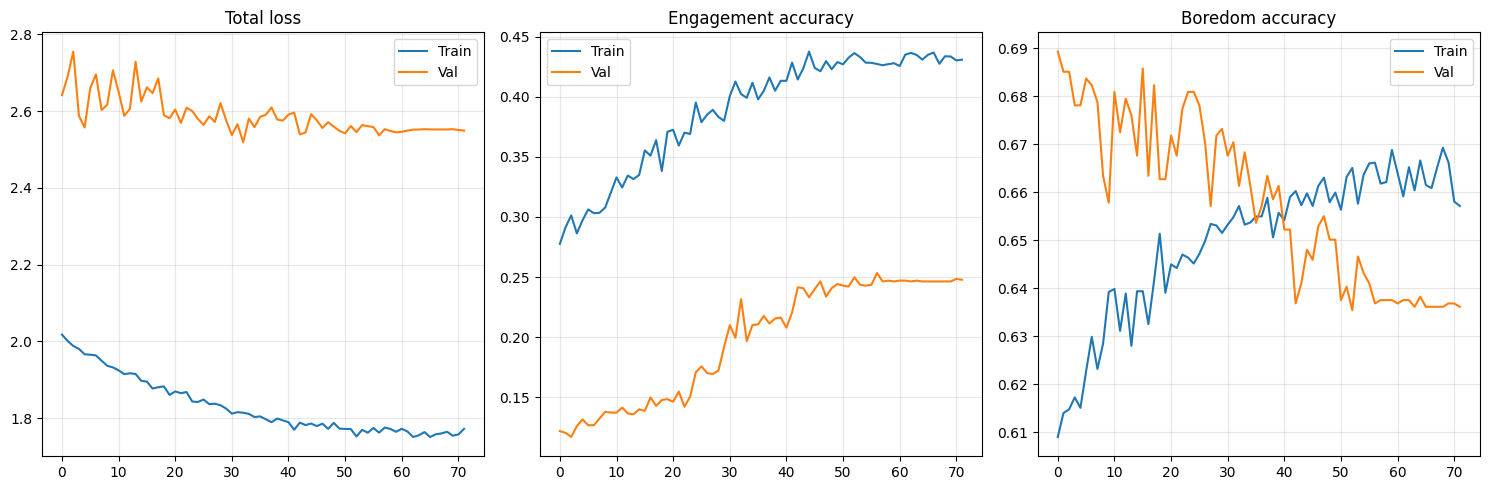

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
axes[0].plot(history.history['loss'],                    label='Train')
axes[0].plot(history.history['val_loss'],                label='Val')
axes[0].set_title('Total loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
 
axes[1].plot(history.history['engagement_accuracy'],     label='Train')
axes[1].plot(history.history['val_engagement_accuracy'], label='Val')
axes[1].set_title('Engagement accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
 
axes[2].plot(history.history['boredom_accuracy'],        label='Train')
axes[2].plot(history.history['val_boredom_accuracy'],    label='Val')
axes[2].set_title('Boredom accuracy')
axes[2].legend(); axes[2].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('training_v5.png', dpi=150)
plt.show()

In [20]:
def calibrate_boredom_threshold(model, X_val, y_bor_val):
    preds  = model.predict(X_val, verbose=0)
    bor_p  = preds['boredom'][:, 1]
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.15, 0.85, 0.02):
        pred = (bor_p >= t).astype(int)
        mf1  = f1_score(y_bor_val, pred, average='macro', zero_division=0)
        if mf1 > best_f1:
            best_f1 = mf1; best_t = t
    print(f"Best boredom threshold: {best_t:.2f}  (macro F1={best_f1:.3f})")
    return float(best_t)
 
 
BOREDOM_THRESHOLD = calibrate_boredom_threshold(
    model, X_val_final, y_bor_val_final)

Best boredom threshold: 0.55  (macro F1=0.562)



TEST SET RESULTS

DAiSEE test  (1784 clips)
Engagement:
              precision    recall  f1-score   support

         Low       0.06      0.80      0.12        88
    Moderate       0.56      0.06      0.11       882
        High       0.51      0.37      0.43       814

    accuracy                           0.24      1784
   macro avg       0.38      0.41      0.22      1784
weighted avg       0.51      0.24      0.25      1784

Boredom:
              precision    recall  f1-score   support

   Not Bored       0.54      0.43      0.48       823
       Bored       0.58      0.69      0.63       961

    accuracy                           0.57      1784
   macro avg       0.56      0.56      0.55      1784
weighted avg       0.56      0.57      0.56      1784


Personal test: no data — skipping

─────────────────────────────────────────────
Test set                   Eng F1     Bor F1
─────────────────────────────────────────────
DAiSEE test                 0.218      0.555


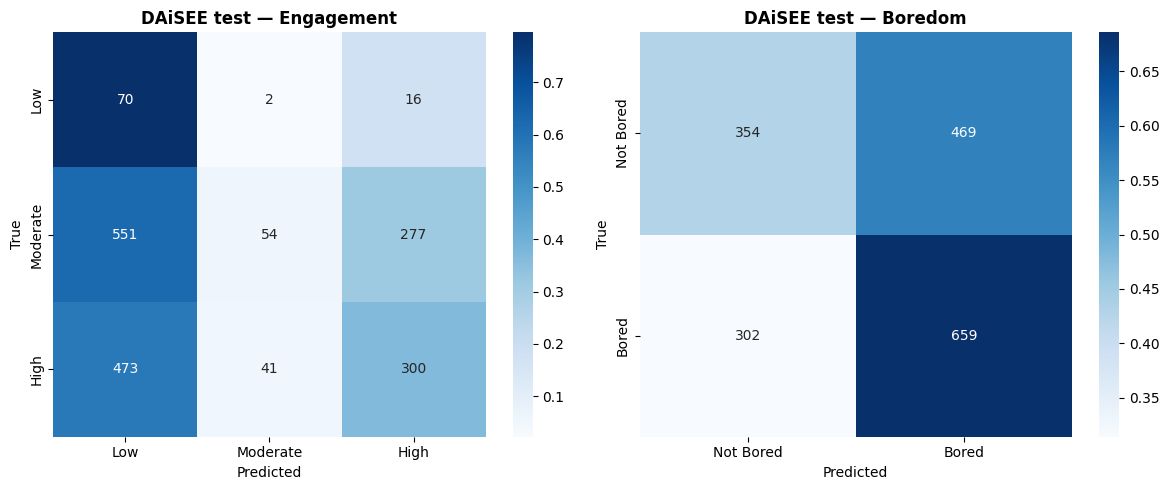

In [23]:
# ── CELL 18: Full evaluation on all test sets ──────────────────────────────────
def evaluate_split(model, X, y_eng, y_bor, name, bor_threshold):
    if X is None or y_eng is None or len(X) == 0:
        print(f"\n{name}: no data — skipping")
        return None, None

    preds    = model.predict(X, verbose=0)
    eng_pred = np.argmax(preds['engagement'], axis=1)
    bor_pred = (preds['boredom'][:, 1] >= bor_threshold).astype(int)

    print(f"\n{'='*55}")
    print(f"{name}  ({len(X)} clips)")
    print('='*55)
    print("Engagement:")
    print(classification_report(y_eng, eng_pred,
          target_names=ENGAGEMENT_NAMES, zero_division=0))
    print("Boredom:")
    print(classification_report(y_bor, bor_pred,
          target_names=BOREDOM_NAMES, zero_division=0))

    return (f1_score(y_eng, eng_pred, average='macro', zero_division=0),
            f1_score(y_bor, bor_pred, average='macro', zero_division=0))


print("\n" + "="*55)
print("TEST SET RESULTS")
print("="*55)

test_sets = [
    ("DAiSEE test",   X_d_test_s,  y_eng_d_test,  y_bor_d_test),
    ("Personal test", X_p_test_s,  y_eng_p_test,  y_bor_p_test),
]

# Combined test — only if personal test data actually exists
if X_p_test_s is not None and y_eng_p_test is not None and len(X_p_test_s) > 0:
    test_sets.append((
        "Combined test",
        np.vstack([X_d_test_s, X_p_test_s]),
        np.concatenate([y_eng_d_test, y_eng_p_test]),
        np.concatenate([y_bor_d_test, y_bor_p_test]),
    ))

summary = []
for name, X_t, ye_t, yb_t in test_sets:
    res = evaluate_split(model, X_t, ye_t, yb_t, name, BOREDOM_THRESHOLD)
    # FIX: explicitly check both values are not None
    if res[0] is not None and res[1] is not None:
        summary.append((name, res[0], res[1]))

# Summary table
print(f"\n{'─'*45}")
print(f"{'Test set':<22} {'Eng F1':>10} {'Bor F1':>10}")
print(f"{'─'*45}")
for name, ef, bf in summary:
    print(f"{name:<22} {ef:>10.3f} {bf:>10.3f}")

# Confusion matrices — only for splits that have data
valid_sets = [
    (name, X_t, ye_t, yb_t)
    for name, X_t, ye_t, yb_t in test_sets
    if X_t is not None and ye_t is not None and len(X_t) > 0
]

n_sets = len(valid_sets)
if n_sets == 0:
    print("No test data available for confusion matrices.")
else:
    fig, axes = plt.subplots(n_sets, 2, figsize=(12, 5 * n_sets))
    if n_sets == 1:
        axes = [axes]

    for row, (name, X_t, ye_t, yb_t) in enumerate(valid_sets):
        preds    = model.predict(X_t, verbose=0)
        eng_pred = np.argmax(preds['engagement'], axis=1)
        bor_pred = (preds['boredom'][:, 1] >= BOREDOM_THRESHOLD).astype(int)

        for col, (yt, yp, names, title) in enumerate([
            (ye_t, eng_pred, ENGAGEMENT_NAMES, 'Engagement'),
            (yb_t, bor_pred, BOREDOM_NAMES,    'Boredom'),
        ]):
            cm   = confusion_matrix(yt, yp)
            cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
            sns.heatmap(cm_n, annot=cm, fmt='d', cmap='Blues',
                        ax=axes[row][col],
                        xticklabels=names, yticklabels=names)
            axes[row][col].set_title(f'{name} — {title}', fontweight='bold')
            axes[row][col].set_xlabel('Predicted')
            axes[row][col].set_ylabel('True')

    plt.tight_layout()
    plt.savefig('eval_v5_all.png', dpi=150)
    plt.show()

In [22]:
model.save('engagetrack_v5_final.keras')
print("Model saved: engagetrack_v5_final.keras")

Model saved: engagetrack_v5_final.keras
